# SMS Spam Classification with Logic Tensor Networks

This notebook demonstrates:
1. Loading the SMS Spam Collection dataset
2. Using OpenAI API with structured outputs to extract features from SMS messages
3. Converting messages to tabular data using boolean and numeric features
4. Creating logical rules for classification
5. Training Logic Tensor Networks (LTN) with the extracted features and rules

## Setup and Imports

In [25]:
import os
import json
import time
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
from tqdm import tqdm

# Load environment variables
from dotenv import load_dotenv

# OpenAI
from openai import OpenAI, RateLimitError, APIError
from pydantic import BaseModel, Field

# TensorFlow and LTN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import ltn

# Set random seeds for reproducibility
np.random.seed(99)
tf.random.set_seed(99)

## Configuration

In [28]:
# Load environment variables from secrets.env
load_dotenv('../secrets.env')

# Paths
DATA_DIR = Path("../input/sms_spam")
DATA_FILE = DATA_DIR / "SMSSpamCollection.tsv"
CACHE_FILE = DATA_DIR / "tags_cache.json"  # Changed from features_cache.json

# OpenAI API
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in secrets.env file")
client = OpenAI(api_key=api_key)

# Training parameters
TEST_SIZE = 0.3
RANDOM_STATE = 42

## 1. Load SMS Dataset

In [29]:
def load_sms_dataset() -> Tuple[List[str], List[int]]:
    """
    Load SMS messages and labels from the dataset.
    Returns:
        messages: List of SMS text messages
        labels: List of binary labels (1 = spam, 0 = ham)
    """
    messages = []
    labels = []
    
    with open(DATA_FILE, 'r', encoding='utf-8') as f:
        for line in f:
            # Tab-separated: label<tab>message
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                label_str, message = parts
                messages.append(message)
                labels.append(1 if label_str.lower() == 'spam' else 0)
    
    print(f"Loaded {len(messages)} messages")
    print(f"  - Spam: {sum(labels)} messages ({sum(labels)/len(labels)*100:.1f}%)")
    print(f"  - Ham: {len(labels) - sum(labels)} messages ({(len(labels)-sum(labels))/len(labels)*100:.1f}%)")
    
    return messages, labels

messages, labels = load_sms_dataset()

Loaded 5574 messages
  - Spam: 747 messages (13.4%)
  - Ham: 4827 messages (86.6%)


In [30]:
# Show sample messages
print("Sample SPAM messages:")
print("-" * 60)
spam_indices = [i for i, label in enumerate(labels) if label == 1][:5]
for idx in spam_indices:
    print(f"[{idx}] {messages[idx][:100]}..." if len(messages[idx]) > 100 else f"[{idx}] {messages[idx]}")

print("\nSample HAM messages:")
print("-" * 60)
ham_indices = [i for i, label in enumerate(labels) if label == 0][:5]
for idx in ham_indices:
    print(f"[{idx}] {messages[idx][:100]}..." if len(messages[idx]) > 100 else f"[{idx}] {messages[idx]}")

Sample SPAM messages:
------------------------------------------------------------
[2] Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entr...
[5] FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it s...
[8] WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim...
[9] Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera f...
[11] SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6day...

Sample HAM messages:
------------------------------------------------------------
[0] Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got a...
[1] Ok lar... Joking wif u oni...
[3] U dun say so early hor... U c already then say...
[4] Nah I don't think he goes to usf, he lives around here though
[6] Even my brother is not like

## 2. Define Output Schema for Tag Extraction

We use OpenAI to extract descriptive tags from each SMS message. The model infers relevant features based on a short description of the dataset - no predefined feature schema is provided.

In [31]:
# Dataset description for ChatGPT to infer relevant features
DATASET_DESCRIPTION = "SMS messages labeled as spam or ham (legitimate) for spam detection classification."

# Output schema - simple list of tags per message
class MessageTags(BaseModel):
    """Tags extracted from a single SMS message."""
    tags: List[str] = Field(description="List of descriptive tags for this message")

class BatchMessageTags(BaseModel):
    """Batch response containing tags for multiple SMS messages."""
    results: List[MessageTags] = Field(description="List of tags for each message in the batch, in order")

print(f"Dataset description: {DATASET_DESCRIPTION}")
print(f"Output format: List of tags per message (features inferred by model)")

Dataset description: SMS messages labeled as spam or ham (legitimate) for spam detection classification.
Output format: List of tags per message (features inferred by model)


## 3. Extract Tags using OpenAI (Batched)

We use OpenAI to extract descriptive tags from SMS messages. The model infers relevant features based on a one-sentence dataset description.

- **Batch size: 50 messages** per API call (~112 batches for 5,574 messages)
- **Token usage and cost** are logged per batch
- Tags are returned as simple lists with no other text

In [32]:
# GPT-5.1 pricing (verify current rates at https://openai.com/pricing)
# Placeholder values - update with actual pricing
PRICE_PER_1M_INPUT_TOKENS = 1.00   # Update with actual gpt-5.1 pricing
PRICE_PER_1M_OUTPUT_TOKENS = 2.00  # Update with actual gpt-5.1 pricing

MODEL_NAME = "gpt-5.1"

# Track total usage across all batches
total_usage = {
    'input_tokens': 0,
    'output_tokens': 0,
    'total_cost': 0.0,
    'batches_processed': 0
}


def extract_tags_batch(messages_batch: List[str], max_retries: int = 5) -> Tuple[Optional[List[List[str]]], Dict]:
    """
    Use OpenAI API to extract tags from a batch of SMS messages.
    
    Args:
        messages_batch: List of SMS messages to analyze (batch size: 50)
        max_retries: Maximum number of retry attempts
    
    Returns:
        Tuple of (list of tag lists for each message, usage stats dict)
    """
    # Format messages with indices
    formatted_messages = "\n".join([
        f"[{i}] {msg}" for i, msg in enumerate(messages_batch)
    ])
    
    usage_stats = {'input_tokens': 0, 'output_tokens': 0, 'cost': 0.0}
    
    for attempt in range(max_retries):
        try:
            response = client.beta.chat.completions.parse(
                model=MODEL_NAME,
                messages=[
                    {
                        "role": "system",
                        "content": f"""You are analyzing messages from this dataset: {DATASET_DESCRIPTION}

For EACH message in the batch (identified by [0], [1], etc.), extract relevant descriptive tags that could help classify the message.

Guidelines:
- Use lowercase tags with underscores (e.g., "has_url", "mentions_prize", "urgent_tone")
- Include both content-based tags (what the message contains) and style-based tags (how it's written)
- Be consistent with tag naming across messages
- Return ONLY tags, no explanations or other text
- Return tags for ALL messages in the exact order provided"""
                    },
                    {
                        "role": "user",
                        "content": f"Extract tags for these {len(messages_batch)} messages:\n\n{formatted_messages}"
                    }
                ],
                response_format=BatchMessageTags,
            )
            
            # Extract usage statistics
            if response.usage:
                usage_stats['input_tokens'] = response.usage.prompt_tokens
                usage_stats['output_tokens'] = response.usage.completion_tokens
                input_cost = (usage_stats['input_tokens'] / 1_000_000) * PRICE_PER_1M_INPUT_TOKENS
                output_cost = (usage_stats['output_tokens'] / 1_000_000) * PRICE_PER_1M_OUTPUT_TOKENS
                usage_stats['cost'] = input_cost + output_cost
            
            parsed = response.choices[0].message.parsed
            
            # Extract just the tag lists
            tags_lists = [msg_tags.tags for msg_tags in parsed.results]
            
            # Verify we got the right number of results
            if len(tags_lists) != len(messages_batch):
                print(f"  WARNING: Expected {len(messages_batch)} results, got {len(tags_lists)}")
                # Pad with empty lists if we got fewer
                while len(tags_lists) < len(messages_batch):
                    tags_lists.append([])
            
            return tags_lists, usage_stats
            
        except RateLimitError as e:
            wait_time = (2 ** attempt) + (0.5 * attempt)
            print(f"  ERROR [RateLimit]: {str(e)[:100]}")
            print(f"         Waiting {wait_time:.1f}s (attempt {attempt + 1}/{max_retries})...")
            time.sleep(wait_time)
            
            if attempt == max_retries - 1:
                print(f"  FAILED: Rate limit not resolved after {max_retries} attempts")
                return None, usage_stats
                
        except APIError as e:
            wait_time = 2 * (attempt + 1)
            print(f"  ERROR [API]: {str(e)[:150]}")
            print(f"         Waiting {wait_time}s (attempt {attempt + 1}/{max_retries})...")
            time.sleep(wait_time)
            
            if attempt == max_retries - 1:
                print(f"  FAILED: API error not resolved after {max_retries} attempts")
                return None, usage_stats
                
        except Exception as e:
            print(f"  ERROR [Unexpected]: {type(e).__name__}: {str(e)[:150]}")
            return None, usage_stats
    
    return None, usage_stats


print(f"Batch tag extraction configured for model: {MODEL_NAME}")
print(f"  - Pricing: ${PRICE_PER_1M_INPUT_TOKENS}/1M input tokens, ${PRICE_PER_1M_OUTPUT_TOKENS}/1M output tokens")

Batch tag extraction configured for model: gpt-5.1
  - Pricing: $1.0/1M input tokens, $2.0/1M output tokens


## 4. Feature Caching System

Features are cached to JSON after each batch to:
- Avoid losing progress if interrupted
- Skip already-processed messages on subsequent runs
- Allow incremental processing of new messages

In [33]:
def load_tags_cache() -> Dict[str, List[str]]:
    """Load cached tags from JSON file."""
    if CACHE_FILE.exists():
        with open(CACHE_FILE, 'r') as f:
            return json.load(f)
    return {}

def save_tags_cache(cache: Dict[str, List[str]]):
    """Save tags cache to JSON file."""
    with open(CACHE_FILE, 'w') as f:
        json.dump(cache, f, indent=2)

def get_message_key(message: str) -> str:
    """Create a unique key for a message (hash of first 100 chars + length)."""
    import hashlib
    content = f"{message[:100]}_{len(message)}"
    return hashlib.md5(content.encode()).hexdigest()

def extract_and_cache_tags_batched(messages: List[str], 
                                    force_refresh: bool = False,
                                    batch_size: int = 50,
                                    delay_between_batches: float = 1.0) -> Dict[str, List[str]]:
    """
    Extract tags for all messages using batched API requests with caching.
    Logs token usage and cost per batch.
    
    Args:
        messages: List of all SMS messages
        force_refresh: If True, re-extract all tags ignoring cache
        batch_size: Number of messages per API request (default: 50)
        delay_between_batches: Delay in seconds between batch requests
    
    Returns:
        Dictionary mapping message keys to their extracted tags
    """
    global total_usage
    
    cache = {} if force_refresh else load_tags_cache()
    
    # Reset total usage tracking
    total_usage = {'input_tokens': 0, 'output_tokens': 0, 'total_cost': 0.0, 'batches_processed': 0}
    
    # Find messages that need processing
    messages_to_process = []
    for idx, msg in enumerate(messages):
        msg_key = get_message_key(msg)
        if msg_key not in cache:
            messages_to_process.append((idx, msg, msg_key))
    
    if not messages_to_process:
        print(f"All {len(messages)} messages already cached")
        return cache
    
    # Calculate number of batches
    num_batches = (len(messages_to_process) + batch_size - 1) // batch_size
    print(f"Processing {len(messages_to_process)} messages in {num_batches} batches (batch_size={batch_size})")
    print("-" * 80)
    
    # Process in batches
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, len(messages_to_process))
        batch = messages_to_process[start_idx:end_idx]
        
        # Extract just the messages for this batch
        batch_messages = [msg for _, msg, _ in batch]
        
        # Call batched API
        tags_lists, usage_stats = extract_tags_batch(batch_messages)
        
        # Update total usage
        total_usage['input_tokens'] += usage_stats['input_tokens']
        total_usage['output_tokens'] += usage_stats['output_tokens']
        total_usage['total_cost'] += usage_stats['cost']
        total_usage['batches_processed'] += 1
        
        # Log batch results
        status = "OK" if tags_lists else "FAILED"
        print(f"Batch {batch_idx + 1:3d}/{num_batches} | {status:6s} | "
              f"Tokens: {usage_stats['input_tokens']:5d} in, {usage_stats['output_tokens']:5d} out | "
              f"Cost: ${usage_stats['cost']:.4f} | "
              f"Running total: ${total_usage['total_cost']:.4f}")
        
        if tags_lists:
            # Store results in cache
            for (_, _, msg_key), tags in zip(batch, tags_lists):
                cache[msg_key] = tags
        else:
            # Store empty tags on failure
            print(f"  -> Storing empty tags for {len(batch)} messages in failed batch")
            for _, _, msg_key in batch:
                cache[msg_key] = []
        
        # Save cache after each batch
        save_tags_cache(cache)
        
        # Delay between batches (except for the last one)
        if batch_idx < num_batches - 1 and delay_between_batches > 0:
            time.sleep(delay_between_batches)
    
    # Print summary
    print("-" * 80)
    print(f"COMPLETE: {total_usage['batches_processed']} batches processed")
    print(f"  Total tokens: {total_usage['input_tokens']:,} input + {total_usage['output_tokens']:,} output = {total_usage['input_tokens'] + total_usage['output_tokens']:,} total")
    print(f"  Total cost: ${total_usage['total_cost']:.4f}")
    print(f"  Cache size: {len(cache)} messages")
    
    return cache

In [35]:
# Extract tags for all messages using batched requests
# Set force_refresh=True to re-extract all tags
# batch_size=50 means ~112 API calls for 5574 messages
tags_cache = extract_and_cache_tags_batched(
    messages,
    force_refresh=False,
    batch_size=150,
    delay_between_batches=1.0
)

print(f"\nTotal messages with tags: {len(tags_cache)}")

# Show example tags
example_key = get_message_key(messages[spam_indices[0]])
print(f"\nExample SPAM tags:")
print(f"Message: {messages[spam_indices[0]][:80]}...")
print(f"Tags: {tags_cache[example_key]}")

example_key_ham = get_message_key(messages[ham_indices[0]])
print(f"\nExample HAM tags:")
print(f"Message: {messages[ham_indices[0]][:80]}...")
print(f"Tags: {tags_cache[example_key_ham]}")

Processing 5574 messages in 38 batches (batch_size=150)
--------------------------------------------------------------------------------
Batch   1/38 | OK     | Tokens:  4257 in,  2299 out | Cost: $0.0089 | Running total: $0.0089
Batch   2/38 | OK     | Tokens:  3931 in,  2020 out | Cost: $0.0080 | Running total: $0.0168
Batch   3/38 | OK     | Tokens:  4164 in,  2414 out | Cost: $0.0090 | Running total: $0.0258
Batch   4/38 | OK     | Tokens:  4064 in,  2342 out | Cost: $0.0087 | Running total: $0.0346
Batch   5/38 | OK     | Tokens:  3968 in,  2325 out | Cost: $0.0086 | Running total: $0.0432
Batch   6/38 | OK     | Tokens:  4465 in,  2602 out | Cost: $0.0097 | Running total: $0.0529
Batch   7/38 | OK     | Tokens:  4001 in,  2581 out | Cost: $0.0092 | Running total: $0.0620
Batch   8/38 | OK     | Tokens:  4022 in,  2389 out | Cost: $0.0088 | Running total: $0.0708
Batch   9/38 | OK     | Tokens:  3777 in,  2332 out | Cost: $0.0084 | Running total: $0.0793
Batch  10/38 | OK     | To

KeyboardInterrupt: 

## 5. Convert to Tabular Dataset

In [9]:

# Reserved column names that should not be used as tags
RESERVED_COLUMNS = {'message', 'label', 'image_path', 'index'}


def is_valid_tag(tag: str) -> bool:
    """
    Check if a tag is valid (not message content or gibberish).
    Valid tags are short, lowercase, use underscores, no spaces in middle.
    """
    if not tag or not isinstance(tag, str):
        return False
    tag = tag.strip()
    # Too long - likely message content
    if len(tag) > 50:
        return False
    # Empty after strip
    if len(tag) == 0:
        return False
    # Contains multiple spaces (likely a sentence)
    if '  ' in tag or tag.count(' ') > 3:
        return False
    # Starts with capital and has spaces (likely a sentence)
    if tag[0].isupper() and ' ' in tag:
        return False
    # Check if normalized tag is a reserved column name
    normalized = tag.strip().lower().replace(' ', '_').replace('-', '_')
    normalized = ''.join(c for c in normalized if c.isalnum() or c == '_')
    if normalized in RESERVED_COLUMNS:
        return False
    return True


def normalize_tag(tag: str) -> str:
    """Normalize a tag to lowercase with underscores."""
    tag = tag.strip().lower()
    tag = tag.replace(' ', '_').replace('-', '_')
    # Remove any non-alphanumeric chars except underscore
    tag = ''.join(c for c in tag if c.isalnum() or c == '_')
    return tag


def create_tabular_dataset(messages: List[str], 
                           labels: List[int], 
                           tags_cache: Dict[str, List[str]]) -> Tuple[pd.DataFrame, List[str]]:
    """
    Convert SMS dataset to tabular format using extracted tags as boolean features.
    Filters out invalid tags (message content, gibberish, etc.)
    """
    # Collect all unique valid tags
    all_tags = set()
    invalid_count = 0
    for tags in tags_cache.values():
        for tag in tags:
            if is_valid_tag(tag):
                all_tags.add(normalize_tag(tag))
            else:
                invalid_count += 1
    
    all_tags = sorted(list(all_tags))
    print(f"Total unique valid tags: {len(all_tags)}")
    print(f"Invalid tags filtered out: {invalid_count}")
    print(f"Sample tags: {all_tags[:15]}...")
    
    # Create feature matrix
    data = []
    for msg, label in zip(messages, labels):
        msg_key = get_message_key(msg)
        raw_tags = tags_cache.get(msg_key, [])
        # Normalize and filter tags for this message
        msg_tags = set(normalize_tag(t) for t in raw_tags if is_valid_tag(t))
        
        # Create boolean features for each tag
        row = {tag: (tag in msg_tags) for tag in all_tags}
        row['label'] = label
        row['message'] = msg[:100]  # Store truncated message for reference
        
        data.append(row)
    
    df = pd.DataFrame(data)
    
    # Convert boolean columns to int
    for col in all_tags:
        df[col] = df[col].astype(int)
    
    return df, all_tags


# Create tabular dataset
tabular_df, all_tags = create_tabular_dataset(messages, labels, tags_cache)

print(f"\nDataset shape: {tabular_df.shape}")
print(f"Number of tag features: {len(all_tags)}")
print(f"\nFirst few rows (sample tags + label):")
sample_cols = all_tags[:5] + ['label']
print(tabular_df[sample_cols].head(10))


Total unique valid tags: 4044
Invalid tags filtered out: 1
Sample tags: ['abbreviated', 'abbreviated_language', 'abbreviation', 'abbreviation_like_content', 'abbreviation_usage', 'abbreviations', 'abbreviations_numbers', 'abbreviations_numbers_as_words', 'abbreviations_slang', 'absence_message', 'abuse_concern', 'abusive_tone', 'academic_context', 'academic_conversation', 'academic_or_technical_content']...

Dataset shape: (5574, 4046)
Number of tag features: 4044

First few rows (sample tags + label):
   abbreviated  abbreviated_language  abbreviation  abbreviation_like_content  \
0            0                     0             0                          0   
1            0                     0             0                          0   
2            0                     0             0                          0   
3            0                     0             0                          0   
4            0                     0             0                          0   
5     

In [10]:
# Analyze tag frequencies by class
spam_df = tabular_df[tabular_df['label'] == 1]
ham_df = tabular_df[tabular_df['label'] == 0]

# Calculate tag frequencies and differences
tag_stats = []
for tag in all_tags:
    spam_pct = spam_df[tag].mean() * 100
    ham_pct = ham_df[tag].mean() * 100
    diff = spam_pct - ham_pct
    tag_stats.append((tag, spam_pct, ham_pct, diff))

# Sort by absolute difference (most discriminative tags)
tag_stats.sort(key=lambda x: abs(x[3]), reverse=True)

print("Top 20 most discriminative tags:")
print("-" * 70)
print(f"{'Tag':35s} | {'Spam %':>8s} | {'Ham %':>8s} | {'Diff':>8s}")
print("-" * 70)
for tag, spam_pct, ham_pct, diff in tag_stats[:20]:
    print(f"{tag:35s} | {spam_pct:7.1f}% | {ham_pct:7.1f}% | {diff:+7.1f}%")

Top 20 most discriminative tags:
----------------------------------------------------------------------
Tag                                 |   Spam % |    Ham % |     Diff
----------------------------------------------------------------------
has_phone_number                    |    21.3% |     0.7% |   +20.6%
urgent_tone                         |    21.2% |     2.2% |   +18.9%
spam_like                           |    18.5% |     0.1% |   +18.4%
informal_language                   |     5.4% |    22.1% |   -16.8%
mentions_prize                      |    15.1% |     0.5% |   +14.7%
casual_tone                         |     7.0% |    20.9% |   -13.9%
has_url                             |    13.8% |     1.3% |   +12.5%
call_to_action                      |    12.0% |     0.7% |   +11.4%
spam                                |     8.0% |     0.6% |    +7.4%
promotional_tone                    |     5.4% |     0.0% |    +5.3%
premium_rate_number                 |     4.8% |     0.0% |    +4.

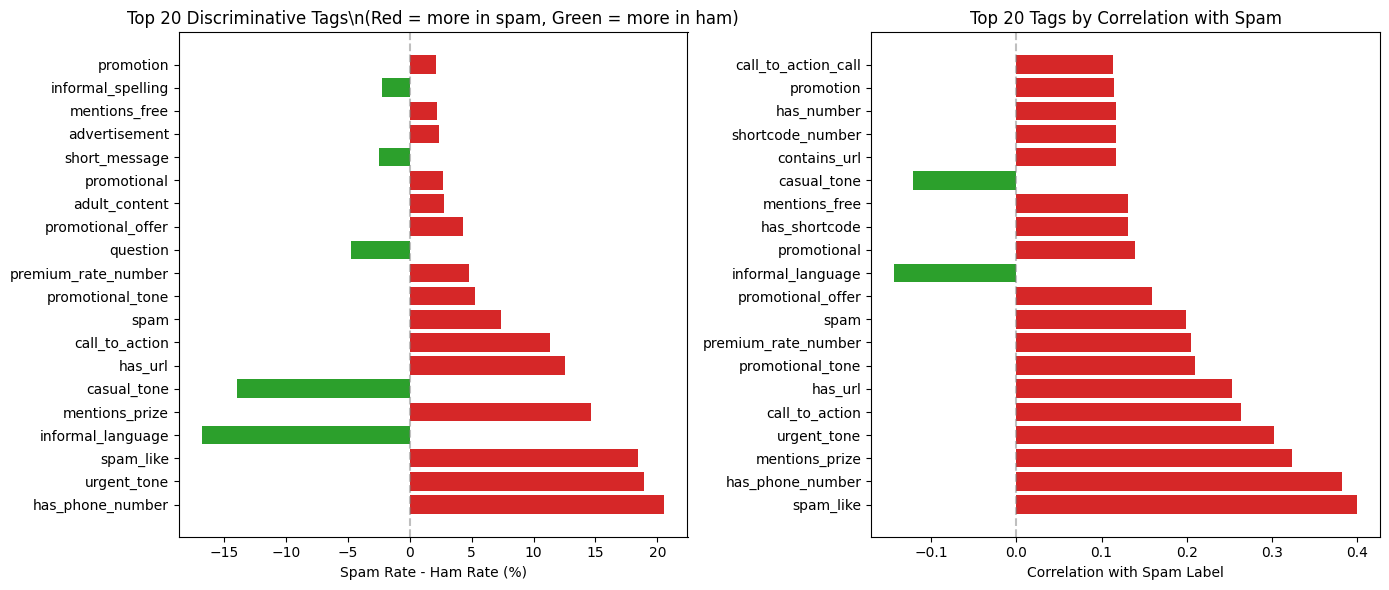

\nTag frequency statistics:
  Most common tag: informal_language (1108 messages)
  Least common tag: youth_slang (1 messages)
  Median frequency: 1 messages
  Tags appearing in >100 messages: 17


In [11]:
# Visualize tag distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top discriminative tags (spam vs ham)
ax = axes[0]
top_20 = tag_stats[:20]
colors = ['#d62728' if d > 0 else '#2ca02c' for _, _, _, d in top_20]
ax.barh([t[0] for t in top_20], [t[3] for t in top_20], color=colors)
ax.set_xlabel('Spam Rate - Ham Rate (%)')
ax.set_title('Top 20 Discriminative Tags\\n(Red = more in spam, Green = more in ham)')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Tag correlation with label
ax = axes[1]
correlations = []
for tag in all_tags:
    corr = tabular_df[tag].corr(tabular_df['label'])
    correlations.append((tag, corr))
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

top_corr = correlations[:20]
colors = ['#d62728' if c > 0 else '#2ca02c' for _, c in top_corr]
ax.barh([f[0] for f in top_corr], [f[1] for f in top_corr], color=colors)
ax.set_xlabel('Correlation with Spam Label')
ax.set_title('Top 20 Tags by Correlation with Spam')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Tag frequency distribution
tag_counts = tabular_df[all_tags].sum().sort_values(ascending=False)
print(f"\\nTag frequency statistics:")
print(f"  Most common tag: {tag_counts.index[0]} ({tag_counts.iloc[0]} messages)")
print(f"  Least common tag: {tag_counts.index[-1]} ({tag_counts.iloc[-1]} messages)")
print(f"  Median frequency: {tag_counts.median():.0f} messages")
print(f"  Tags appearing in >100 messages: {(tag_counts > 100).sum()}")

## 6. Define LTN Predicates and Rules

In [12]:
# =============================================================================
# STEP 1: Identify most discriminative tags for rules
# =============================================================================

# Get top spam-indicative tags (positive correlation)
spam_tags = [(tag, corr) for tag, corr in correlations if corr > 0.1][:10]

# Get top ham-indicative tags (negative correlation)
ham_tags = [(tag, corr) for tag, corr in correlations if corr < -0.1][:10]

print("Top spam-indicative tags (correlation > 0.1):")
for tag, corr in spam_tags:
    print(f"  {tag}: {corr:.3f}")

print(f"\\nTop ham-indicative tags (correlation < -0.1):")
for tag, corr in ham_tags:
    print(f"  {tag}: {corr:.3f}")

# Create mapping from tag name to column index
def get_tag_index(tag_name: str) -> int:
    """Get the column index for a tag in the feature matrix."""
    return all_tags.index(tag_name)

# Store selected tags for rule generation
SPAM_INDICATOR_TAGS = [tag for tag, _ in spam_tags[:5]]  # Top 5 spam indicators
HAM_INDICATOR_TAGS = [tag for tag, _ in ham_tags[:5]]    # Top 5 ham indicators

print(f"\\nSelected for rules:")
print(f"  Spam indicators: {SPAM_INDICATOR_TAGS}")
print(f"  Ham indicators: {HAM_INDICATOR_TAGS}")

Top spam-indicative tags (correlation > 0.1):
  spam_like: 0.399
  has_phone_number: 0.382
  mentions_prize: 0.323
  urgent_tone: 0.302
  call_to_action: 0.264
  has_url: 0.252
  promotional_tone: 0.209
  premium_rate_number: 0.205
  spam: 0.199
  promotional_offer: 0.160
\nTop ham-indicative tags (correlation < -0.1):
  informal_language: -0.143
  casual_tone: -0.121
\nSelected for rules:
  Spam indicators: ['spam_like', 'has_phone_number', 'mentions_prize', 'urgent_tone', 'call_to_action']
  Ham indicators: ['informal_language', 'casual_tone']


In [13]:
# =============================================================================
# STEP 2: Define LTN Fuzzy Logic Operators
# =============================================================================

Not = ltn.Wrapper_Connective(ltn.fuzzy_ops.Not_Std())
And = ltn.Wrapper_Connective(ltn.fuzzy_ops.And_Prod())
Or = ltn.Wrapper_Connective(ltn.fuzzy_ops.Or_ProbSum())
Implies = ltn.Wrapper_Connective(ltn.fuzzy_ops.Implies_Reichenbach())
Forall = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMeanError(p=2), semantics="forall")
Exists = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMean(p=2), semantics="exists")

formula_aggregator = ltn.Wrapper_Formula_Aggregator(ltn.fuzzy_ops.Aggreg_pMeanError(p=2))

print("LTN operators defined")

LTN operators defined


In [14]:
# =============================================================================
# STEP 3: Define Predicates (dynamically based on discovered tags)
# =============================================================================

# Create predicates for spam-indicative tags
spam_predicates = {}
for tag in SPAM_INDICATOR_TAGS:
    idx = get_tag_index(tag)
    spam_predicates[tag] = ltn.Predicate(lambda x, i=idx: tf.cast(x[:, i] > 0.5, tf.float32))

# Create predicates for ham-indicative tags
ham_predicates = {}
for tag in HAM_INDICATOR_TAGS:
    idx = get_tag_index(tag)
    ham_predicates[tag] = ltn.Predicate(lambda x, i=idx: tf.cast(x[:, i] > 0.5, tf.float32))

print("Predicates defined dynamically from discovered tags:")
print(f"  Spam predicates ({len(spam_predicates)}): {list(spam_predicates.keys())}")
print(f"  Ham predicates ({len(ham_predicates)}): {list(ham_predicates.keys())}")

Predicates defined dynamically from discovered tags:
  Spam predicates (5): ['spam_like', 'has_phone_number', 'mentions_prize', 'urgent_tone', 'call_to_action']
  Ham predicates (2): ['informal_language', 'casual_tone']


In [15]:
# =============================================================================
# STEP 4: Prepare Data
# =============================================================================

# Prepare data for LTN - using all tags as features
X = tabular_df[all_tags].values.astype(np.float32)
y = tabular_df['label'].values.astype(bool)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of tag features: {X_train.shape[1]}")
print(f"\\nClass distribution:")
print(f"  Train - Spam: {y_train.sum()} ({y_train.mean()*100:.1f}%), Ham: {(~y_train).sum()} ({(~y_train).mean()*100:.1f}%)")
print(f"  Test  - Spam: {y_test.sum()} ({y_test.mean()*100:.1f}%), Ham: {(~y_test).sum()} ({(~y_test).mean()*100:.1f}%)")

Training set: 3901 samples
Test set: 1673 samples
Number of tag features: 4044
\nClass distribution:
  Train - Spam: 523 (13.4%), Ham: 3378 (86.6%)
  Test  - Spam: 224 (13.4%), Ham: 1449 (86.6%)


## 7. RULES_ONLY Model

Pure Python lambda-based rule evaluation (no neural network).

In [16]:
# =============================================================================
# RULES_ONLY MODEL (dynamic based on discovered tags)
# =============================================================================

import random

# Boolean operators
def PyAnd(a, b): return a and b
def PyOr(a, b): return a or b
def PyNot(a): return not a

# Create Python predicates dynamically
py_spam_predicates = {}
for tag in SPAM_INDICATOR_TAGS:
    idx = get_tag_index(tag)
    py_spam_predicates[tag] = lambda x, i=idx: x[i] > 0.5

py_ham_predicates = {}
for tag in HAM_INDICATOR_TAGS:
    idx = get_tag_index(tag)
    py_ham_predicates[tag] = lambda x, i=idx: x[i] > 0.5

# Target predicates
py_is_spam = lambda x, y: 1
py_is_ham = lambda x, y: 0

def build_rules_python(x, y):
    """Build rules dynamically from discovered tags."""
    rules = []
    
    # Spam rules: if any spam indicator tag is present -> spam
    for tag in SPAM_INDICATOR_TAGS[:3]:  # Top 3 spam indicators
        rules.append((py_spam_predicates[tag](x), py_is_spam(x, y)))
    
    # Combined spam rule: if 2+ spam indicators -> spam
    spam_count = sum(1 for tag in SPAM_INDICATOR_TAGS if py_spam_predicates[tag](x))
    rules.append((spam_count >= 2, py_is_spam(x, y)))
    
    # Ham rules: if any ham indicator tag is present AND no spam indicators -> ham
    for tag in HAM_INDICATOR_TAGS[:2]:  # Top 2 ham indicators
        no_spam = all(not py_spam_predicates[st](x) for st in SPAM_INDICATOR_TAGS[:3])
        rules.append((PyAnd(py_ham_predicates[tag](x), no_spam), py_is_ham(x, y)))
    
    return rules

def rules_only_predict(X, Y):
    """Predict using rules only (first matching rule wins)."""
    preds = []
    for x, y in zip(X, Y):
        rules = build_rules_python(x, y)
        # Default: random if no rule matches
        rules.append((True, random.choice([0, 1])))
        
        for rule_premise, rule_result in rules:
            if rule_premise:
                preds.append(rule_result)
                break
    return np.array(preds)


print("RULES_ONLY model defined with dynamic rules:")
print(f"  Spam indicator tags used: {SPAM_INDICATOR_TAGS[:3]}")
print(f"  Ham indicator tags used: {HAM_INDICATOR_TAGS[:2]}")
print("  Rules:")
print("    - If any top-3 spam tag present -> spam")
print("    - If 2+ spam indicator tags present -> spam")
print("    - If ham tag present AND no spam tags -> ham")

RULES_ONLY model defined with dynamic rules:
  Spam indicator tags used: ['spam_like', 'has_phone_number', 'mentions_prize']
  Ham indicator tags used: ['informal_language', 'casual_tone']
  Rules:
    - If any top-3 spam tag present -> spam
    - If 2+ spam indicator tags present -> spam
    - If ham tag present AND no spam tags -> ham


## 8. Neural Network and LTN Training

In [17]:
# =============================================================================
# STEP 5: Define Neural Network f and Knowledge Axioms
# =============================================================================

# The neural network predicate
f = ltn.Predicate.MLP([(X_train.shape[1],)], hidden_layer_sizes=(16, 16))

# Target predicates
is_spam = lambda x, y: f(x)
is_ham = lambda x, y: Not(f(x))

# Create predicates for the knowledge axiom
# Tags needed: has_url, promotional (for promotional content), urgent_tone
has_url_idx = get_tag_index('has_url')
promotional_idx = get_tag_index('promotional_tone')  # Using promotional_tone for promotional content
urgent_tone_idx = get_tag_index('urgent_tone')

HasUrl = ltn.Predicate(lambda x, i=has_url_idx: tf.cast(x[:, i] > 0.5, tf.float32))
PromotionalContent = ltn.Predicate(lambda x, i=promotional_idx: tf.cast(x[:, i] > 0.5, tf.float32))
UrgentTone = ltn.Predicate(lambda x, i=urgent_tone_idx: tf.cast(x[:, i] > 0.5, tf.float32))

def build_ltn_knowledge_axioms(x, f_model):
    """
    Build LTN knowledge axiom:
    If the message does not contain a URL or (has promotional content but not an urgent tone)
    then it is not spam.
    
    In logic: ¬has_url ∨ (promotional_content ∧ ¬urgent_tone) → ¬spam
    """
    axioms = []
    
    # Axiom: ¬has_url ∨ (promotional_content ∧ ¬urgent_tone) → ¬spam
    axioms.append(
        Forall(x, 
            Implies(
                Or(
                    Not(HasUrl(x)),
                    And(PromotionalContent(x), Not(UrgentTone(x)))
                ),
                Not(f_model(x))
            )
        )
    )
    
    return axioms

print(f"Neural network f created with input size: {X_train.shape[1]}")
print(f"Knowledge axiom: ¬has_url ∨ (promotional_content ∧ ¬urgent_tone) → ¬spam")
print(f"  - has_url index: {has_url_idx}")
print(f"  - promotional_tone index: {promotional_idx}")
print(f"  - urgent_tone index: {urgent_tone_idx}")

Neural network f created with input size: 4044
Knowledge axiom: ¬has_url ∨ (promotional_content ∧ ¬urgent_tone) → ¬spam
  - has_url index: 1419
  - promotional_tone index: 2951
  - urgent_tone index: 3886


In [18]:
# =============================================================================
# STEP 6: Training Function
# =============================================================================

def create_and_train_model(X_train, y_train, X_test, y_test,
                           use_rules, max_epochs=200, learning_rate=0.001,
                           patience=50, min_delta=1e-5, model_name="Model"):
    """
    Create and train a new LTN model.
    """
    # Create fresh neural network
    f_model = ltn.Predicate.MLP([(X_train.shape[1],)], hidden_layer_sizes=(16, 16))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    train_losses = []
    val_balanced_accs = []
    
    best_loss = float('inf')
    epochs_without_improvement = 0
    best_val_balanced_acc = 0.0
    best_val_acc_epoch = 0
    best_weights = None
    
    print(f"\\n{'='*60}")
    print(f"Training {model_name} (use_rules={use_rules})")
    print(f"{'='*60}")
    
    for epoch in range(max_epochs):
        with tf.GradientTape() as tape:
            x = ltn.Variable("x", X_train)
            x_A = ltn.Variable("x_A", tf.boolean_mask(X_train, y_train))
            x_not_A = ltn.Variable("x_not_A", tf.boolean_mask(X_train, tf.logical_not(y_train)))
            
            # Base axioms (supervised)
            base_axioms = [
                Forall(x_A, f_model(x_A)),
                Forall(x_not_A, Not(f_model(x_not_A)))
            ]
            
            axioms = base_axioms
            
            if use_rules:
                # Add knowledge axioms from discovered tags
                knowledge_axioms = build_ltn_knowledge_axioms(x, f_model)
                axioms = base_axioms + knowledge_axioms
            
            sat_level = formula_aggregator(axioms).tensor
            loss = 1.0 - sat_level
        
        gradients = tape.gradient(loss, f_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, f_model.trainable_variables))
        train_loss = loss.numpy()
        train_losses.append(train_loss)
        
        # Validation
        val_preds = f_model.model(X_test).numpy()
        val_preds_binary = (val_preds > 0.5).astype(int).flatten()
        val_balanced_acc = balanced_accuracy_score(y_test.astype(int), val_preds_binary)
        val_balanced_accs.append(val_balanced_acc)
        
        # Best model tracking
        if val_balanced_acc > best_val_balanced_acc:
            best_val_balanced_acc = val_balanced_acc
            best_val_acc_epoch = epoch + 1
            best_weights = [w.numpy().copy() for w in f_model.trainable_variables]
        
        # Early stopping
        if train_loss < best_loss - min_delta:
            best_loss = train_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}] - Train Loss: {train_loss:.4f}, Val BalAcc: {val_balanced_acc:.4f}, Best: {best_val_balanced_acc:.4f} (ep {best_val_acc_epoch})")
        
        if epochs_without_improvement >= patience:
            print(f"\\nEarly stopping at epoch {epoch+1}!")
            break
    
    # Restore best weights
    if best_weights is not None:
        print(f"\\nRestoring best model from epoch {best_val_acc_epoch} (Val BalAcc: {best_val_balanced_acc:.4f})")
        for var, weight in zip(f_model.trainable_variables, best_weights):
            var.assign(weight)
    
    history = {
        'train_loss': train_losses,
        'val_balanced_acc': val_balanced_accs,
        'best_epoch': best_val_acc_epoch,
        'best_val_balanced_acc': best_val_balanced_acc
    }
    
    return f_model, history, epoch + 1

In [19]:
# =============================================================================
# Train both MLP and LTN models
# =============================================================================

# Train MLP (base axioms only)
mlp_model, mlp_history, mlp_epochs = create_and_train_model(
    X_train, y_train, X_test, y_test,
    use_rules=False, max_epochs=1000, patience=50, model_name="MLP"
)

# Train LTN (base axioms + knowledge rules)
ltn_model, ltn_history, ltn_epochs = create_and_train_model(
    X_train, y_train, X_test, y_test,
    use_rules=True, max_epochs=1000, patience=50, model_name="LTN"
)

print("\n" + "="*60)
print("Training completed!")
print(f"MLP: best at epoch {mlp_history['best_epoch']} (BalAcc: {mlp_history['best_val_balanced_acc']:.4f})")
print(f"LTN: best at epoch {ltn_history['best_epoch']} (BalAcc: {ltn_history['best_val_balanced_acc']:.4f})")
print("="*60)

\n============================================================
Training MLP (use_rules=False)
Epoch [50] - Train Loss: 0.3337, Val BalAcc: 0.7908, Best: 0.7915 (ep 46)
Epoch [100] - Train Loss: 0.2435, Val BalAcc: 0.7590, Best: 0.7937 (ep 60)
Epoch [150] - Train Loss: 0.2156, Val BalAcc: 0.7411, Best: 0.7937 (ep 60)
Epoch [200] - Train Loss: 0.2053, Val BalAcc: 0.7268, Best: 0.7937 (ep 60)
Epoch [250] - Train Loss: 0.2004, Val BalAcc: 0.7180, Best: 0.7937 (ep 60)
Epoch [300] - Train Loss: 0.1976, Val BalAcc: 0.7149, Best: 0.7937 (ep 60)
Epoch [350] - Train Loss: 0.1957, Val BalAcc: 0.7136, Best: 0.7937 (ep 60)
Epoch [400] - Train Loss: 0.1943, Val BalAcc: 0.7139, Best: 0.7937 (ep 60)
Epoch [450] - Train Loss: 0.1928, Val BalAcc: 0.7125, Best: 0.7937 (ep 60)
Epoch [500] - Train Loss: 0.1910, Val BalAcc: 0.7139, Best: 0.7937 (ep 60)
Epoch [550] - Train Loss: 0.1889, Val BalAcc: 0.7029, Best: 0.7937 (ep 60)
Epoch [600] - Train Loss: 0.1861, Val BalAcc: 0.7003, Best: 0.7937 (ep 60)
Epoch [

## 9. Evaluation and Comparison

In [20]:
# =============================================================================
# Model Comparison
# =============================================================================

def evaluate_model(model_func, X, y, model_name):
    """Evaluate a model and return metrics."""
    preds = model_func(X, y)
    
    if isinstance(preds, np.ndarray) and preds.dtype == np.float32:
        preds_binary = (preds > 0.5).astype(int).flatten()
    else:
        preds_binary = np.array(preds).astype(int).flatten()
    
    y_true = np.array(y).astype(int).flatten()
    
    metrics = {
        'Accuracy': accuracy_score(y_true, preds_binary),
        'Balanced Accuracy': balanced_accuracy_score(y_true, preds_binary),
        'Precision': precision_score(y_true, preds_binary, zero_division=0),
        'Recall': recall_score(y_true, preds_binary, zero_division=0),
        'F1 Score': f1_score(y_true, preds_binary, zero_division=0),
    }
    
    return metrics, preds_binary


# Define prediction functions
def rules_only_func(X, y):
    return rules_only_predict(X, y)

def mlp_func(X, y):
    return mlp_model.model(X).numpy()

def ltn_func(X, y):
    return ltn_model.model(X).numpy()


# Evaluate all models
print("=" * 70)
print("MODEL COMPARISON - TEST SET RESULTS")
print("=" * 70)

models = {
    'RULES_ONLY': rules_only_func,
    'MLP': mlp_func,
    'LTN': ltn_func
}

results = {}
predictions = {}

for model_name, model_func in models.items():
    metrics, preds = evaluate_model(model_func, X_test, y_test, model_name)
    results[model_name] = metrics
    predictions[model_name] = preds

# Display comparison table
comparison_df = pd.DataFrame(results).T.round(4)
print("\nMetrics Comparison:")
print("-" * 70)
print(comparison_df.to_string())
print("-" * 70)

# Best model per metric
print("\nBest Model per Metric:")
for metric in comparison_df.columns:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"  {metric}: {best_model} ({best_value:.4f})")

MODEL COMPARISON - TEST SET RESULTS

Metrics Comparison:
----------------------------------------------------------------------
            Accuracy  Balanced Accuracy  Precision  Recall  F1 Score
RULES_ONLY    0.6814             0.6651     0.2412  0.6429    0.3508
MLP           0.8715             0.7937     0.5151  0.6875    0.5889
LTN           0.9014             0.7732     0.6411  0.5982    0.6189
----------------------------------------------------------------------

Best Model per Metric:
  Accuracy: LTN (0.9014)
  Balanced Accuracy: MLP (0.7937)
  Precision: LTN (0.6411)
  Recall: MLP (0.6875)
  F1 Score: LTN (0.6189)


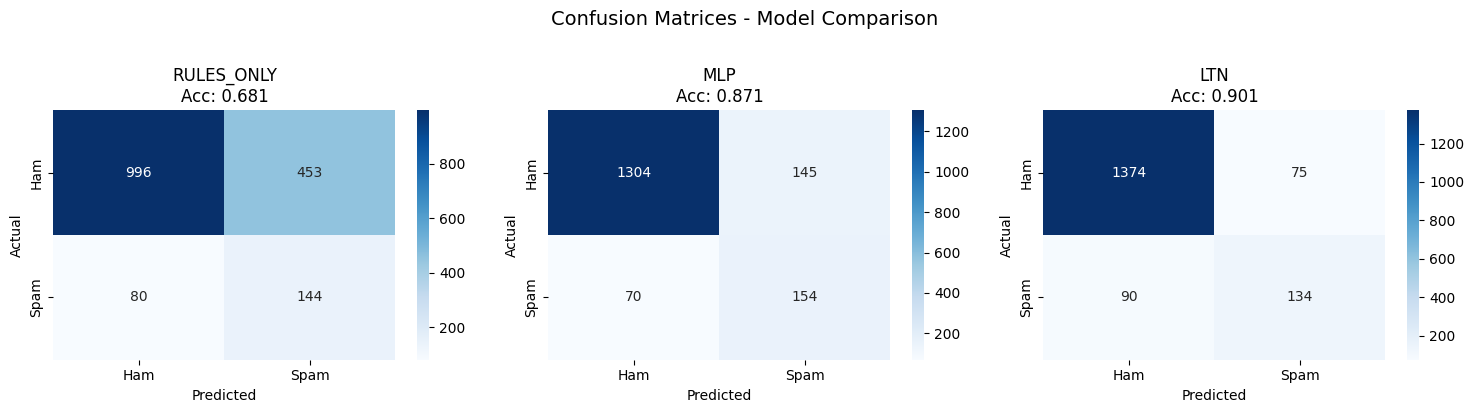

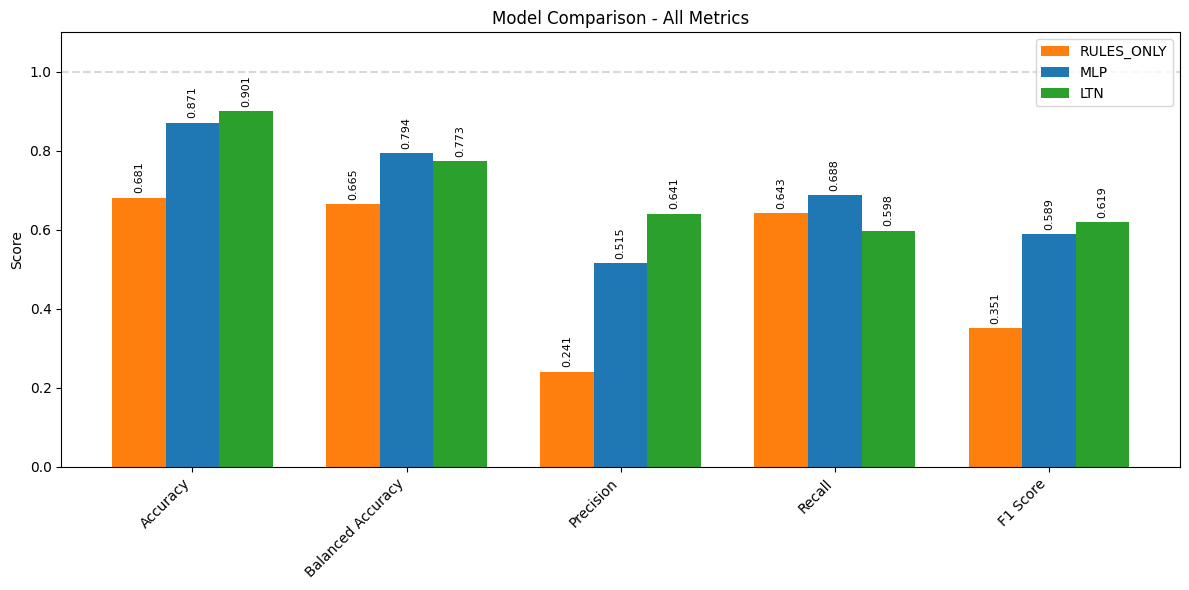

In [21]:
# =============================================================================
# Visualization
# =============================================================================

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, preds) in enumerate(predictions.items()):
    ax = axes[idx]
    cm = confusion_matrix(y_test.astype(int), preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name}\nAcc: {results[model_name]["Accuracy"]:.3f}')

plt.suptitle('Confusion Matrices - Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Bar chart comparison
metrics_to_plot = ['Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, [results['RULES_ONLY'][m] for m in metrics_to_plot],
               width, label='RULES_ONLY', color='#ff7f0e')
bars2 = ax.bar(x, [results['MLP'][m] for m in metrics_to_plot],
               width, label='MLP', color='#1f77b4')
bars3 = ax.bar(x + width, [results['LTN'][m] for m in metrics_to_plot],
               width, label='LTN', color='#2ca02c')

ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

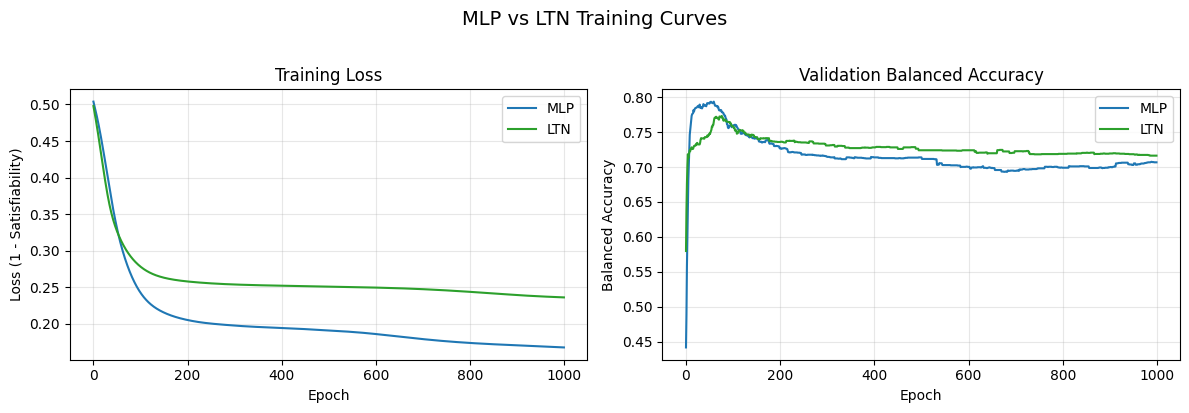

In [22]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training loss
ax = axes[0]
ax.plot(mlp_history['train_loss'], label='MLP', color='#1f77b4')
ax.plot(ltn_history['train_loss'], label='LTN', color='#2ca02c')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (1 - Satisfiability)')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Validation balanced accuracy
ax = axes[1]
ax.plot(mlp_history['val_balanced_acc'], label='MLP', color='#1f77b4')
ax.plot(ltn_history['val_balanced_acc'], label='LTN', color='#2ca02c')
ax.set_xlabel('Epoch')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Validation Balanced Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('MLP vs LTN Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# =============================================================================
# Detailed Classification Report
# =============================================================================

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for model_name, preds in predictions.items():
    print(f"\n{model_name}:")
    print("-" * 50)
    print(classification_report(y_test.astype(int), preds, target_names=['Ham', 'Spam']))


DETAILED CLASSIFICATION REPORTS

RULES_ONLY:
--------------------------------------------------
              precision    recall  f1-score   support

         Ham       0.93      0.69      0.79      1449
        Spam       0.24      0.64      0.35       224

    accuracy                           0.68      1673
   macro avg       0.58      0.67      0.57      1673
weighted avg       0.83      0.68      0.73      1673


MLP:
--------------------------------------------------
              precision    recall  f1-score   support

         Ham       0.95      0.90      0.92      1449
        Spam       0.52      0.69      0.59       224

    accuracy                           0.87      1673
   macro avg       0.73      0.79      0.76      1673
weighted avg       0.89      0.87      0.88      1673


LTN:
--------------------------------------------------
              precision    recall  f1-score   support

         Ham       0.94      0.95      0.94      1449
        Spam       0.64   

In [24]:
# =============================================================================
# Summary
# =============================================================================

print("=" * 70)
print("STRUCTURE SUMMARY")
print("=" * 70)

print(f"\\n1. TAG EXTRACTION (OpenAI with inferred features):")
print(f"   Dataset description: \"{DATASET_DESCRIPTION}\"")
print(f"   Total unique tags discovered: {len(all_tags)}")
print(f"   Batch size: 50 messages per API call")

print(f"\\n2. DISCRIMINATIVE TAGS (auto-selected for rules):")
print(f"   Spam indicators: {SPAM_INDICATOR_TAGS}")
print(f"   Ham indicators: {HAM_INDICATOR_TAGS}")

print(f"\\n3. NEURAL NETWORK:")
print(f"   f = ltn.Predicate.MLP([({X_train.shape[1]},)], hidden_layer_sizes=(16, 16))")

print("\\n4. KNOWLEDGE RULES (dynamically generated):")
print("   Spam rules: spam_tag(x) → spam(x) for each top spam indicator")
print("   Ham rules: ham_tag(x) → ¬spam(x) for each top ham indicator")

print(f"\\n5. TRAINING:")
print(f"   Dataset: {len(messages)} SMS messages ({sum(labels)} spam, {len(labels)-sum(labels)} ham)")
print(f"   Train/Test split: {100-TEST_SIZE*100:.0f}%/{TEST_SIZE*100:.0f}%")
print(f"   MLP epochs: {mlp_epochs}, LTN epochs: {ltn_epochs}")

print(f"\\n6. API USAGE:")
print(f"   Total tokens: {total_usage['input_tokens']:,} input + {total_usage['output_tokens']:,} output")
print(f"   Total cost: ${total_usage['total_cost']:.4f}")

print("\\n" + "=" * 70)

STRUCTURE SUMMARY
\n1. TAG EXTRACTION (OpenAI with inferred features):
   Dataset description: "SMS messages labeled as spam or ham (legitimate) for spam detection classification."
   Total unique tags discovered: 4044
   Batch size: 50 messages per API call
\n2. DISCRIMINATIVE TAGS (auto-selected for rules):
   Spam indicators: ['spam_like', 'has_phone_number', 'mentions_prize', 'urgent_tone', 'call_to_action']
   Ham indicators: ['informal_language', 'casual_tone']
\n3. NEURAL NETWORK:
   f = ltn.Predicate.MLP([(4044,)], hidden_layer_sizes=(16, 16))
\n4. KNOWLEDGE RULES (dynamically generated):
   Spam rules: spam_tag(x) → spam(x) for each top spam indicator
   Ham rules: ham_tag(x) → ¬spam(x) for each top ham indicator
\n5. TRAINING:
   Dataset: 5574 SMS messages (747 spam, 4827 ham)
   Train/Test split: 70%/30%
   MLP epochs: 1000, LTN epochs: 1000
\n6. API USAGE:
   Total tokens: 0 input + 0 output
   Total cost: $0.0000
\n==========================================================